In [1]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import time


df_raw = pd.read_csv('weather_data.csv')

df_raw

,time,city_group,station_name,lat,lon,air_temperature,highest_temperature,lowest_temperature,relative_humidity,wind_speed,maximum_wind_speed,minimum_wind_speed,wind_direction,precipitation_amount,maximum_precipitation_intensity,air_pressure,present_weather_(auto)
0,2026-01-31 14:00:00,Oulu,Oulu Airport,64.93,25.35,-20.0,-19.9,-20.1,81.0,3.1,3.6,2.6,151.0,NaN,NaN,1035.5,0.0
1,2026-01-31 15:00:00,Oulu,Oulu Airport,64.93,25.35,-20.2,-20.1,-20.4,81.0,2.9,3.4,2.6,151.0,NaN,NaN,1035.4,0.0
2,2026-01-31 16:00:00,Oulu,Oulu Airport,64.93,25.35,-20.3,-20.1,-20.6,81.0,3.2,3.4,2.9,150.0,NaN,NaN,1035.3,0.0
3,2026-01-31 17:00:00,Oulu,Oulu Airport,64.93,25.35,-19.8,-19.5,-20.3,81.0,3.0,3.4,2.8,153.0,NaN,NaN,1035.1,0.0
4,2026-01-31 18:00:00,Oulu,Oulu Airport,64.93,25.35,-19.8,-19.5,-20.0,81.0,3.1,3.5,2.7,150.0,NaN,NaN,1035.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16869,2025-12-31 09:00:00,Vaasa,Vaasa Airport,63.05,21.76,-6.8,-6.5,-7.3,94.0,1.1,1.5,0.6,32.0,NaN,NaN,1009.4,71.0
16870,2025-12-31 10:00:00,Vaasa,Vaasa Airport,63.05,21.76,-7.5,-6.9,-8.6,93.0,1.0,1.5,0.5,263.0,NaN,NaN,1009.1,71.0
16871,2025-12-31 11:00:00,Vaasa,Vaasa Airport,63.05,21.76,-9.2,-7.8,-10.9,93.0,0.8,1.3,0.5,208.0,NaN,NaN,1008.6,35.0
16872,2025-12-31 12:00:00,Vaasa,Vaasa Airport,63.05,21.76,-9.6,-7.8,-11.3,93.0,1.0,1.9,0.4,257.0,NaN,NaN,1008.2,20.0


In [2]:
df_raw.isnull().sum()

time                                  0
city_group                            0
station_name                          0
lat                                   0
lon                                   0
air_temperature                       2
highest_temperature                   0
lowest_temperature                    0
relative_humidity                     2
wind_speed                         2204
maximum_wind_speed                 2458
minimum_wind_speed                 2458
wind_direction                     2477
precipitation_amount               6330
maximum_precipitation_intensity    6340
air_pressure                          2
present_weather_(auto)             2153
dtype: int64

## Preprocessing


So we have a few of missing values, I will compensate for this in 2 ways:
- Use multiple centers in one city (and then we can merged the dataset later). I believe that the slight change in distance would not affect the data as a whole
- If there are still missing values, or lack of multiple reliable centers (**Oulu** centers does not have any `precipitation`) we will rely to `present_weather_(auto)` to help us. Since `present_weather_(auto)` give us the current weather status, we can try and deviate the `precipitation` out of this

In [3]:
df_raw['time'] = pd.to_datetime(df_raw['time'])

df_raw = df_raw.sort_values(['city_group', 'time'])
df_merged = df_raw.groupby(['city_group', 'time']).first().reset_index()

df_merged['Time'] = pd.to_datetime(df_merged['time'])
df_merged = df_merged.sort_values(by='time', ascending=True)
df_merged['present_weather_(auto)'].describe()


count    10502.000000
mean        30.424586
std         35.211940
min          0.000000
25%          0.000000
50%          0.000000
75%         71.000000
max         87.000000
Name: present_weather_(auto), dtype: float64

In [4]:
# Define the 'Snow Codes'
snow_codes = [70, 71, 72, 73, 74, 75, 85, 86]
rain_codes = [60, 61, 62, 63, 64, 65, 80, 81]

# Logic: If precip is missing but we have a snow code, 
# fill with 0.1 (trace) to ensure the model knows 'something' fell.
mask_precip_nan = df_merged['precipitation_amount'].isna()

# Snow logic
df_merged.loc[mask_precip_nan & df_merged['present_weather_(auto)'].isin(snow_codes), 'precipitation_amount'] = 0.1

# Rain logic (just in case)
df_merged.loc[mask_precip_nan & df_merged['present_weather_(auto)'].isin(rain_codes), 'precipitation_amount'] = 0.1

# Final Fallback: Everything else becomes 0
df_merged['precipitation_amount'] = df_merged['precipitation_amount'].fillna(0.0)



## Interpolating

I have been researching to find the best stations across Finland's cities that would offer the best quality of data, but most of the observation center would either have missing features (`precipitation`, or `wind speed`).

So we retrieved multiple centers to compensate for this and merge them into cities. 

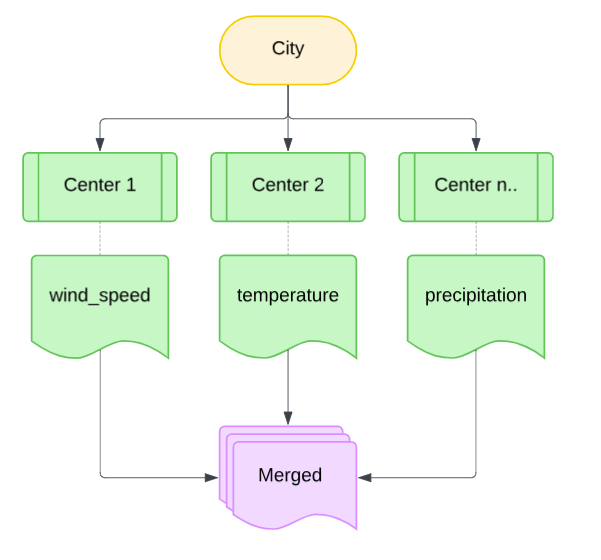



In [5]:
df_merged['wind_speed'] = df_merged.groupby('city_group')['wind_speed'].transform(lambda x: x.interpolate())
df_merged['maximum_wind_speed'] = df_merged.groupby('city_group')['maximum_wind_speed'].transform(lambda x: x.interpolate())
df_merged['minimum_wind_speed'] = df_merged.groupby('city_group')['minimum_wind_speed'].transform(lambda x: x.interpolate())

df_merged['wind_direction'] = df_merged.groupby('city_group')['wind_direction'].ffill()


df_merged['maximum_precipitation_intensity'] = df_merged['maximum_precipitation_intensity'].fillna(0.0)
df_merged['present_weather_(auto)'] = df_merged['present_weather_(auto)'].fillna(0)


df_merged.isnull().sum()

city_group                         0
time                               0
station_name                       0
lat                                0
lon                                0
air_temperature                    2
highest_temperature                0
lowest_temperature                 0
relative_humidity                  2
wind_speed                         0
maximum_wind_speed                 0
minimum_wind_speed                 0
wind_direction                     0
precipitation_amount               0
maximum_precipitation_intensity    0
air_pressure                       2
present_weather_(auto)             0
Time                               0
dtype: int64

Now the rest are very minor missing values so I will drop them

In [6]:
df_merged = df_merged.dropna()

Let's first look at some data for the last 7 days

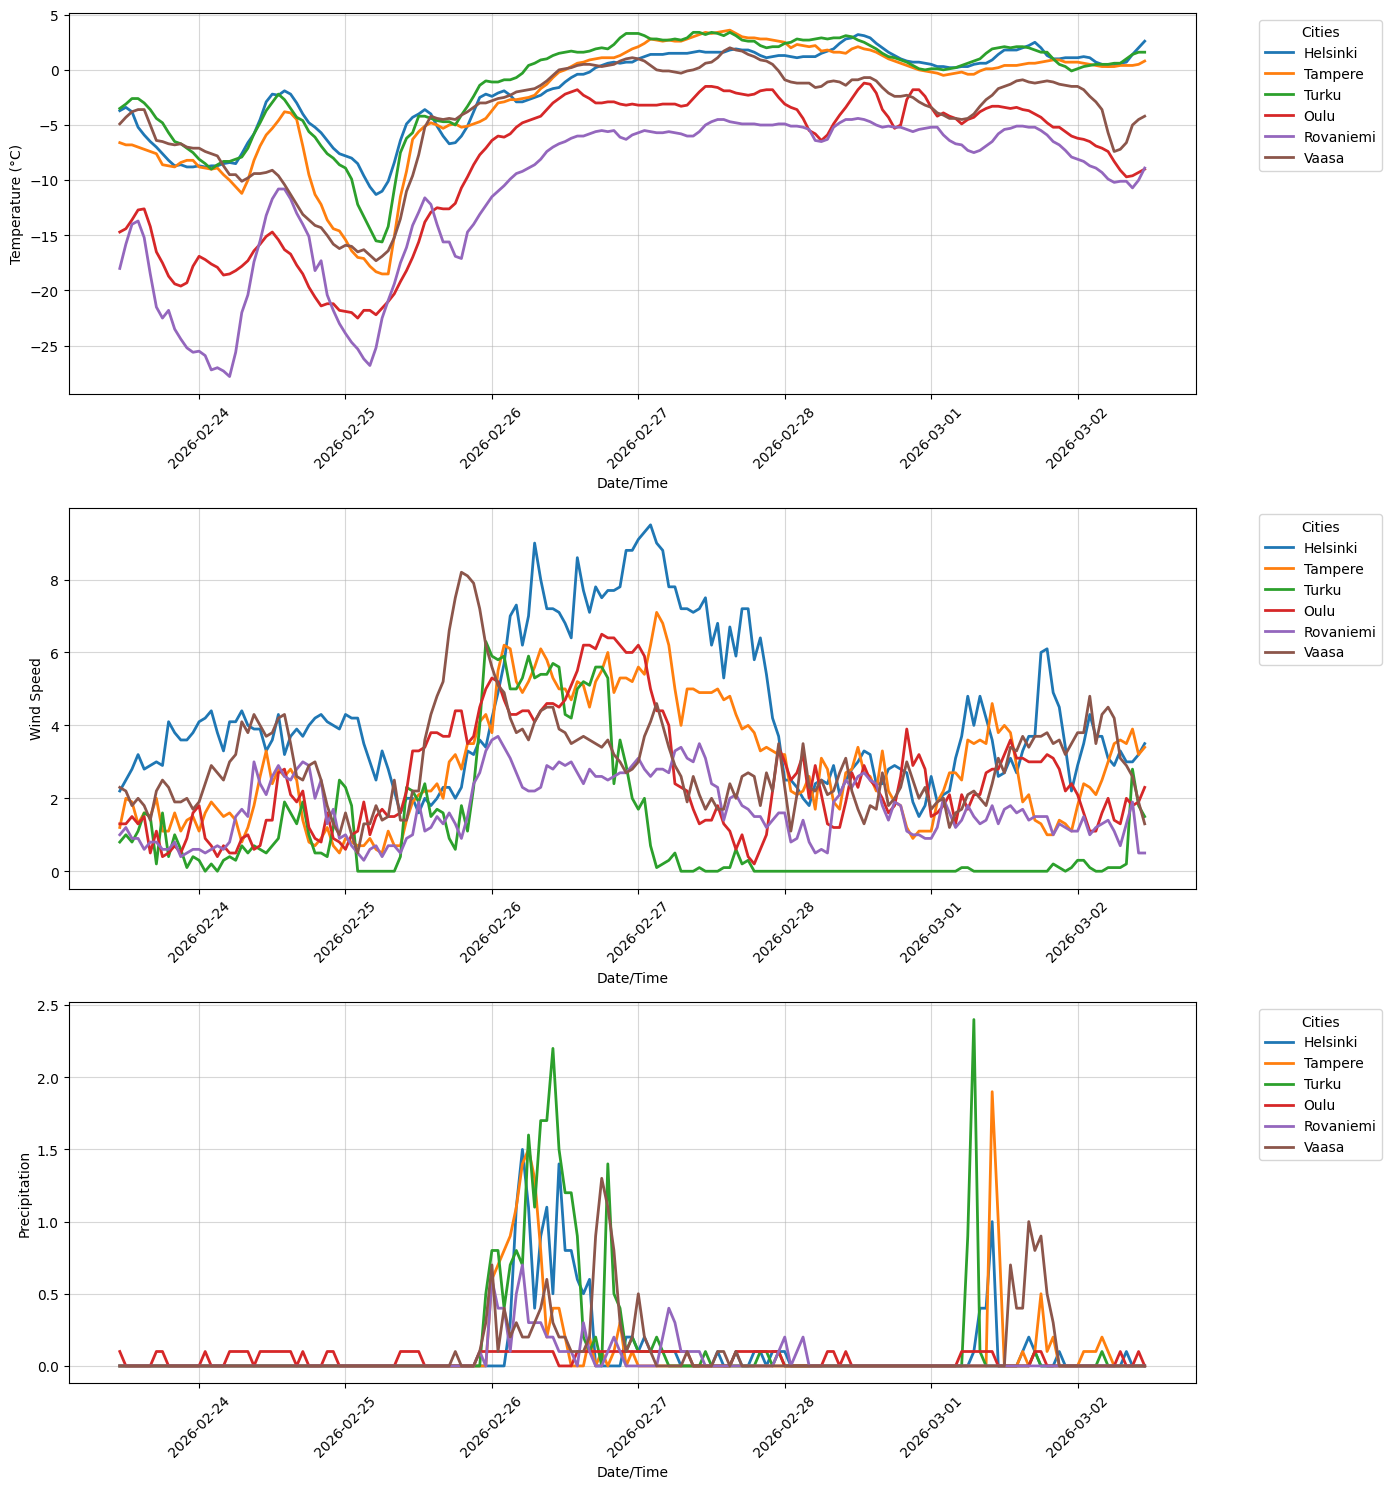

In [7]:
import matplotlib.pyplot as plt

# Filter for the last 7 days
last_date = df_merged['time'].max()
seven_days_ago = last_date - pd.Timedelta(days=7)
plot_df = df_merged[df_merged['time'] >= seven_days_ago].copy()

plt.figure(figsize= (14, 15))

plt.subplot(3, 1, 1)
# Loop through cities and plot
for city in plot_df['city_group'].unique():
    city_data = plot_df[plot_df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['air_temperature'], label=city, linewidth=2)


plt.xlabel('Date/Time')
plt.ylabel('Temperature (°C)')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)


plt.subplot(3, 1, 2)

for city in plot_df['city_group'].unique():
    city_data = plot_df[plot_df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['wind_speed'], label=city, linewidth=2)

plt.xlabel('Date/Time')
plt.ylabel('Wind Speed')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)

plt.subplot(3, 1, 3)

for city in plot_df['city_group'].unique():
    city_data = plot_df[plot_df['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['precipitation_amount'], label=city, linewidth=2)

plt.xlabel('Date/Time')
plt.ylabel('Precipitation')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)


plt.tight_layout()

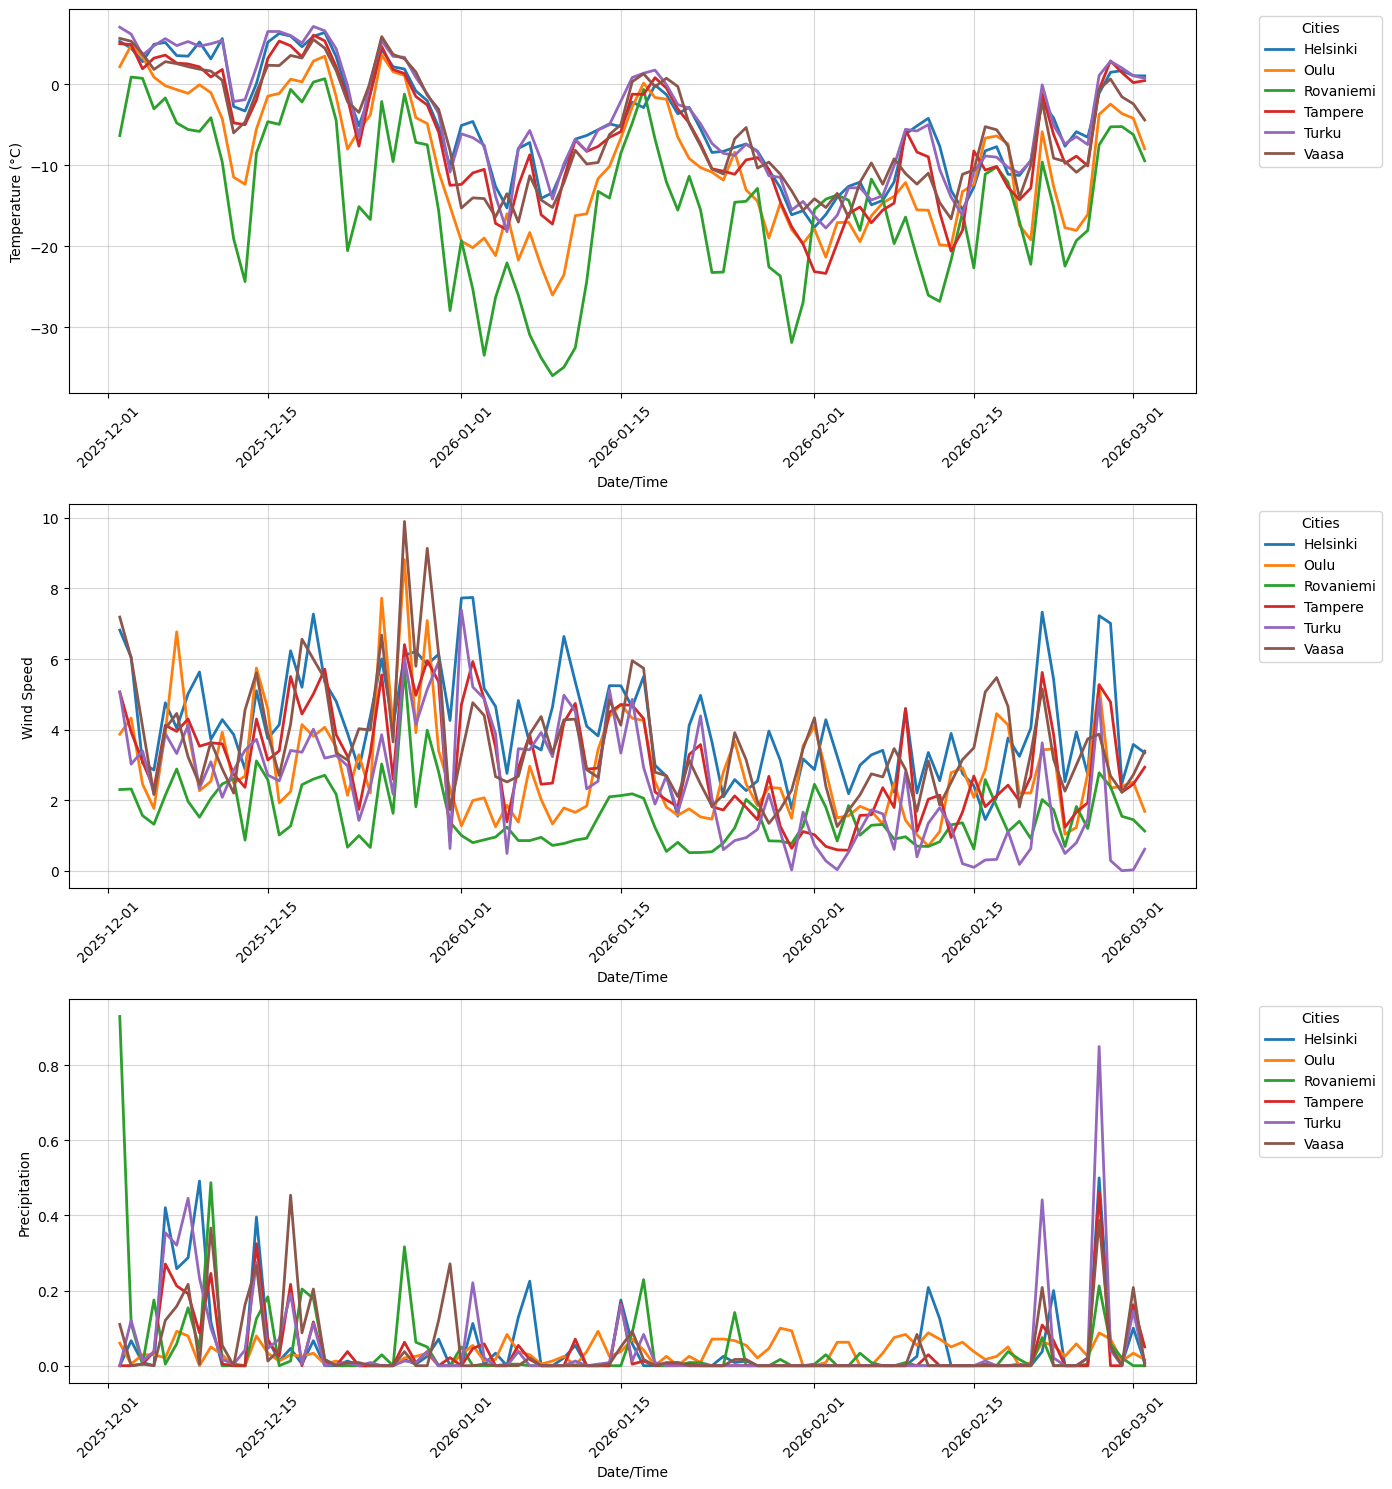

In [8]:
import matplotlib.pyplot as plt

df_daily = df_merged.groupby(['city_group', df_merged['time'].dt.date]).mean(numeric_only=True).reset_index()
df_daily['time'] = pd.to_datetime(df_daily['time'])


plt.figure(figsize= (14, 15))

plt.subplot(3, 1, 1)
# Loop through cities and plot
for city in df_daily['city_group'].unique():
    city_data = df_daily[df_daily['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['air_temperature'], label=city, linewidth=2)


plt.xlabel('Date/Time')
plt.ylabel('Temperature (°C)')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)


plt.subplot(3, 1, 2)

for city in df_daily['city_group'].unique():
    city_data = df_daily[df_daily['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['wind_speed'], label=city, linewidth=2)

plt.xlabel('Date/Time')
plt.ylabel('Wind Speed')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)

plt.subplot(3, 1, 3)

for city in df_daily['city_group'].unique():
    city_data = df_daily[df_daily['city_group'] == city].sort_values('time')
    plt.plot(city_data['time'], city_data['precipitation_amount'], label=city, linewidth=2)

plt.xlabel('Date/Time')
plt.ylabel('Precipitation')
plt.legend(title="Cities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)


plt.tight_layout()

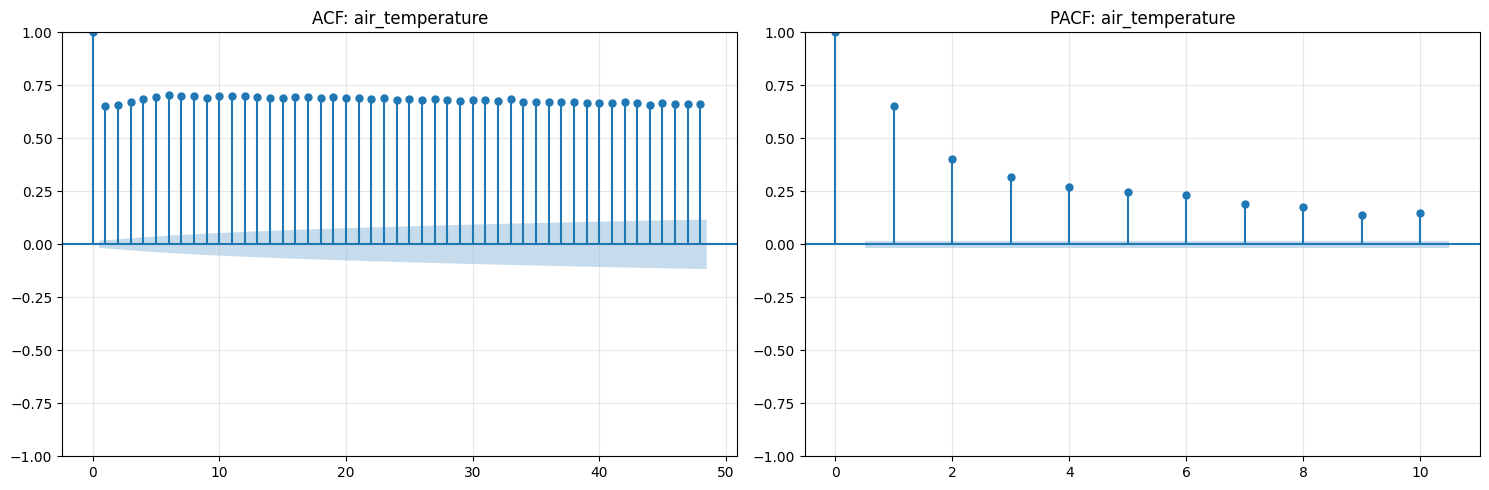

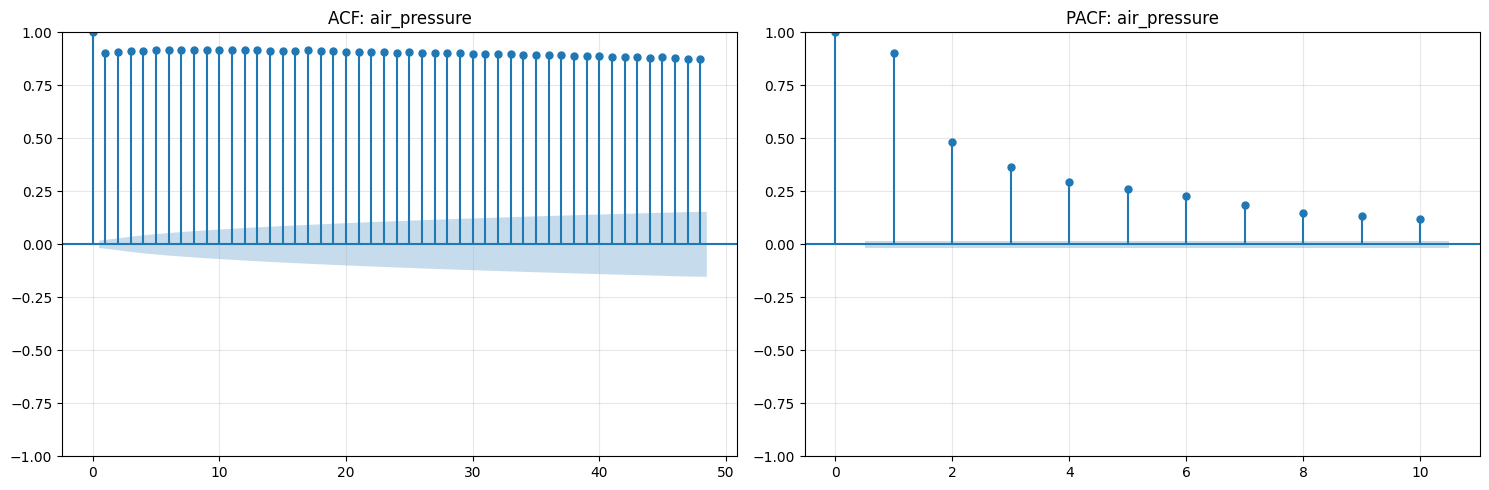

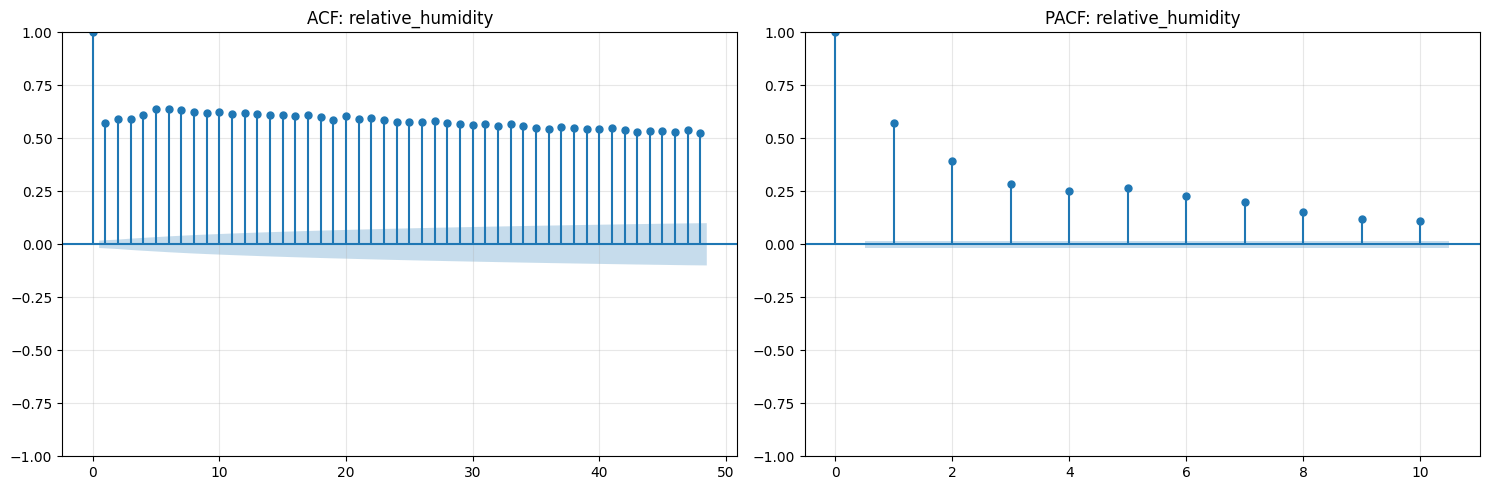

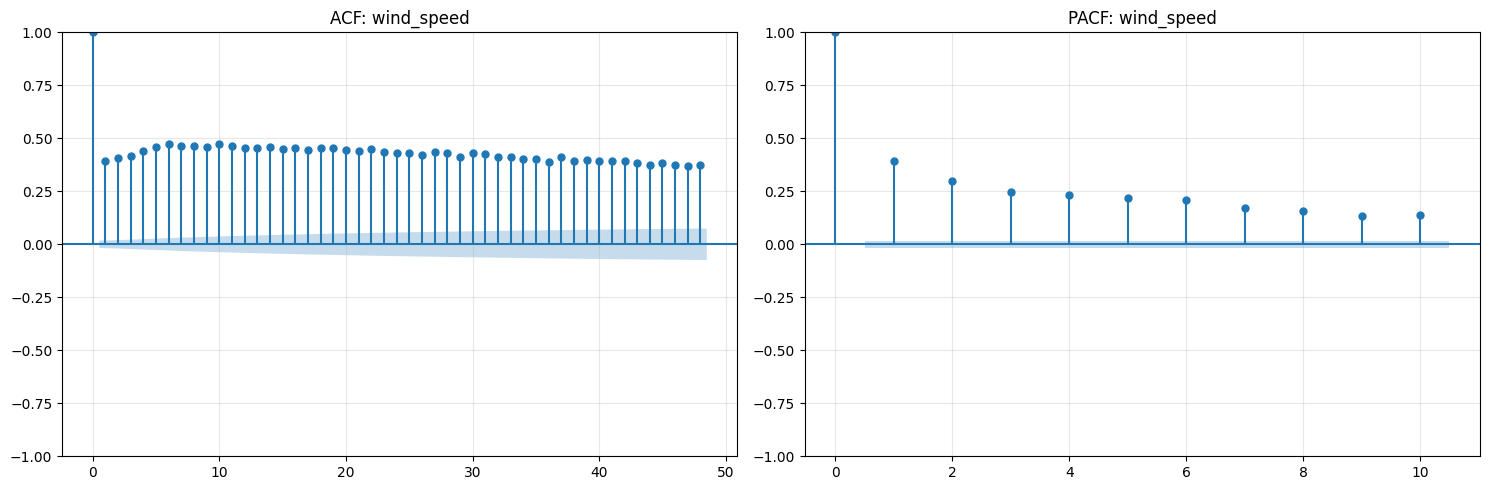

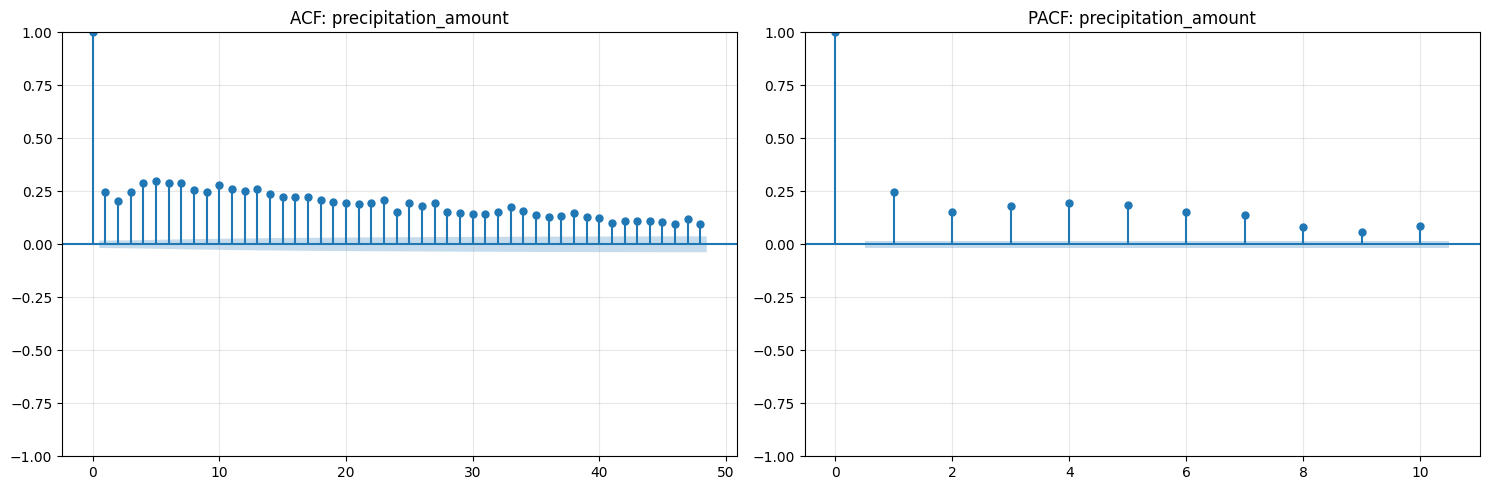

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

feature_to_check = [
    'air_temperature', 'air_pressure', 'relative_humidity', 
    'wind_speed', 'precipitation_amount'
]

for feat in feature_to_check:
    series = df_merged[feat]
    
    if series.empty:
        print(f"Skipping {feat}: No data after dropping NaNs.")
        continue


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    

    plot_acf(series, lags=48, ax=ax1)
    ax1.set_title(f'ACF: {feat}')
    ax1.grid(alpha=0.3)

    plot_pacf(series, lags=10, ax=ax2, method='ywm')
    ax2.set_title(f'PACF: {feat}')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [10]:
df_merged.describe()

,time,lat,lon,air_temperature,highest_temperature,lowest_temperature,relative_humidity,wind_speed,maximum_wind_speed,minimum_wind_speed,wind_direction,precipitation_amount,maximum_precipitation_intensity,air_pressure,present_weather_(auto),Time
count,12653,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653.000000,12653
mean,2026-01-16 12:40:10.147790,62.783892,23.932127,-7.551063,-7.231534,-7.875982,87.281593,2.951079,3.537461,2.364127,170.575200,0.043199,0.168616,1015.380953,25.252430,2026-01-16 12:40:10.147790
min,2025-12-02 14:00:00,60.200000,21.650000,-38.600000,-38.200000,-38.800000,44.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,982.300000,0.000000,2025-12-02 14:00:00
25%,2025-12-24 13:00:00,60.510000,22.200000,-13.300000,-12.800000,-13.800000,83.000000,1.500000,2.000000,0.900000,90.000000,0.000000,0.000000,1007.800000,0.000000,2025-12-24 13:00:00
50%,2026-01-16 12:00:00,63.090000,24.960000,-6.900000,-6.700000,-7.200000,88.000000,2.700000,3.200000,2.100000,161.000000,0.000000,0.000000,1015.700000,0.000000,2026-01-16 12:00:00
75%,2026-02-08 12:00:00,64.930000,25.350000,-0.400000,-0.200000,-0.600000,93.000000,4.100000,4.700000,3.500000,244.000000,0.000000,0.000000,1024.000000,71.000000,2026-02-08 12:00:00
max,2026-03-02 11:00:00,66.560000,25.830000,8.400000,8.500000,8.300000,100.000000,14.100000,16.200000,13.300000,360.000000,3.400000,12.000000,1037.500000,87.000000,2026-03-02 11:00:00
std,NaN,2.334423,1.580503,8.703763,8.580021,8.835671,8.246181,1.931968,2.105134,1.786969,97.651204,0.176116,0.709801,10.672195,34.054444,NaN


In [11]:
df = df_merged.copy()

In [ ]:
df['target_temp'] = df.groupby('city_group')['air_temperature'].shift(-1)
df['target_diff'] = df['target_temp'] - df['air_temperature']


df['temp_lag_1'] = df.groupby('city_group')['air_temperature'].shift(1)

df['temp_change_1'] = df.groupby('city_group')['air_temperature'].diff(1)
df['air_pressure_lag_1'] = df.groupby('city_group')['air_pressure'].shift(1)
df['relative_humidity_lag_1'] = df.groupby('city_group')['relative_humidity'].shift(1)

# Did the pressure drop or rise in the last 3 hours? Mainly use to predict a storm
df['pressure_diff_3h'] = df.groupby('city_group')['air_pressure'].diff(3)

df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


#  For later 1 year approach
# df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
# df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df = df.dropna()

In [65]:
df.columns

Index(['city_group', 'time', 'station_name', 'lat', 'lon', 'air_temperature',
       'highest_temperature', 'lowest_temperature', 'relative_humidity',
       'wind_speed', 'maximum_wind_speed', 'minimum_wind_speed',
       'wind_direction', 'precipitation_amount',
       'maximum_precipitation_intensity', 'air_pressure',
       'present_weather_(auto)', 'Time', 'target_temp', 'temp_lag_1',
       'temp_change_1', 'air_pressure_lag_1', 'relative_humidity_lag_1',
       'pressure_diff_3h', 'hour', 'month', 'hour_sin', 'hour_cos',
       'target_diff', 'temp_lag_24'],
      dtype='str')

In [182]:
feature = [
    'lat', 'lon', 
    'air_temperature', 'temp_lag_1', 
    #    'temp_change_1', 
        # 'temp_lag_24',
       'relative_humidity',
       'wind_speed', 'wind_direction', 
       'precipitation_amount', 'air_pressure',
       'present_weather_(auto)', 
       
       'air_pressure_lag_1', 'relative_humidity_lag_1',
       'pressure_diff_3h', 'hour_sin', 'hour_cos'
]



train_end = int(len(df) * 0.7)
val_end = int(len(df) * 0.85)

df_train = df.iloc[:train_end] 
df_val = df.iloc[train_end:val_end]
df_test = df.iloc[val_end:]

target = 'target_temp'

X_train, X_val, X_test = df_train[feature], df_val[feature], df_test[feature]
y_train, y_val, y_test = df_train['target_temp'], df_val['target_temp'], df_test['target_temp']


print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")


Train size: 8491 | Val size: 1820 | Test size: 1820


In [183]:
# Check how many rows of each city are in each split
for name, split_df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    print(f"\n{name} Split:")
    print(split_df['city_group'].value_counts())


Train Split:
city_group
Helsinki     1416
Vaasa        1416
Rovaniemi    1416
Tampere      1415
Turku        1414
Oulu         1414
Name: count, dtype: int64

Val Split:
city_group
Tampere      305
Vaasa        304
Oulu         303
Rovaniemi    303
Helsinki     303
Turku        302
Name: count, dtype: int64

Test Split:
city_group
Rovaniemi    304
Oulu         304
Helsinki     304
Tampere      303
Vaasa        303
Turku        302
Name: count, dtype: int64


In [184]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

xgb = Pipeline([
    ('xgb', XGBRegressor(
        n_estimators = 1000,
        learning_rate = 0.05,
        random_state = 8,
        early_stopping_rounds = 10
        ))
])

base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

xgb.fit(X_train, y_train,
        xgb__eval_set = [(X_val, y_val)],
        xgb__verbose = 100
        )

base.fit(X_train, y_train)


[0]	validation_0-rmse:7.81148


[100]	validation_0-rmse:0.73889
[175]	validation_0-rmse:0.72214


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


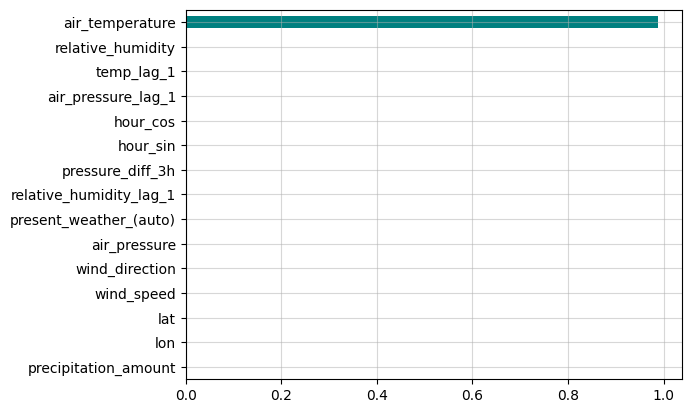

In [185]:
xgb_model = xgb.named_steps['xgb']

feat_imp = pd.Series(xgb_model.feature_importances_, index = feature).sort_values()
feat_imp.plot(kind = "barh", color = 'teal')
plt.grid(alpha = 0.5)
plt.show()

In [186]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

y_xgb = xgb.predict(X_val)

rmse_xgb = root_mean_squared_error(y_true= y_val, y_pred= y_xgb)
mae_xgb = mean_absolute_error(y_true= y_val, y_pred= y_xgb)
r2_xgb = r2_score(y_true= y_val, y_pred= y_xgb)

y_base = base.predict(X_val)

rmse_base = root_mean_squared_error(y_true= y_val, y_pred= y_base)
mae_base = mean_absolute_error(y_true= y_val, y_pred= y_base)
r2_base = r2_score(y_true= y_val, y_pred= y_base)


print("XGB Model: " + 
      f"\n RMSE: {rmse_xgb: .2f}" +
      f"\n MAE: {mae_xgb: .2f}" +
      f"\n R2: {r2_xgb: .2f}") 

print("====================================")

print("Base Model: " + 
      f"\n RMSE: {rmse_base: .2f}" +
      f"\n MAE: {mae_base: .2f}" +
      f"\n R2: {r2_base: .2f}") 



XGB Model: 
 RMSE:  0.72
 MAE:  0.49
 R2:  0.98
Base Model: 
 RMSE:  0.63
 MAE:  0.43
 R2:  0.99


In [194]:
y_xgb_test = xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_true= y_test, y_pred= y_xgb_test)
mae_xgb = mean_absolute_error(y_true= y_test, y_pred= y_xgb_test)
r2_xgb = r2_score(y_true= y_test, y_pred= y_xgb_test)

print("XGB Model: " + 
      f"\n RMSE: {rmse_xgb: .2f}" +
      f"\n MAE: {mae_xgb: .2f}" +
      f"\n R2: {r2_xgb: .2f}") 

XGB Model: 
 RMSE:  0.70
 MAE:  0.46
 R2:  0.99


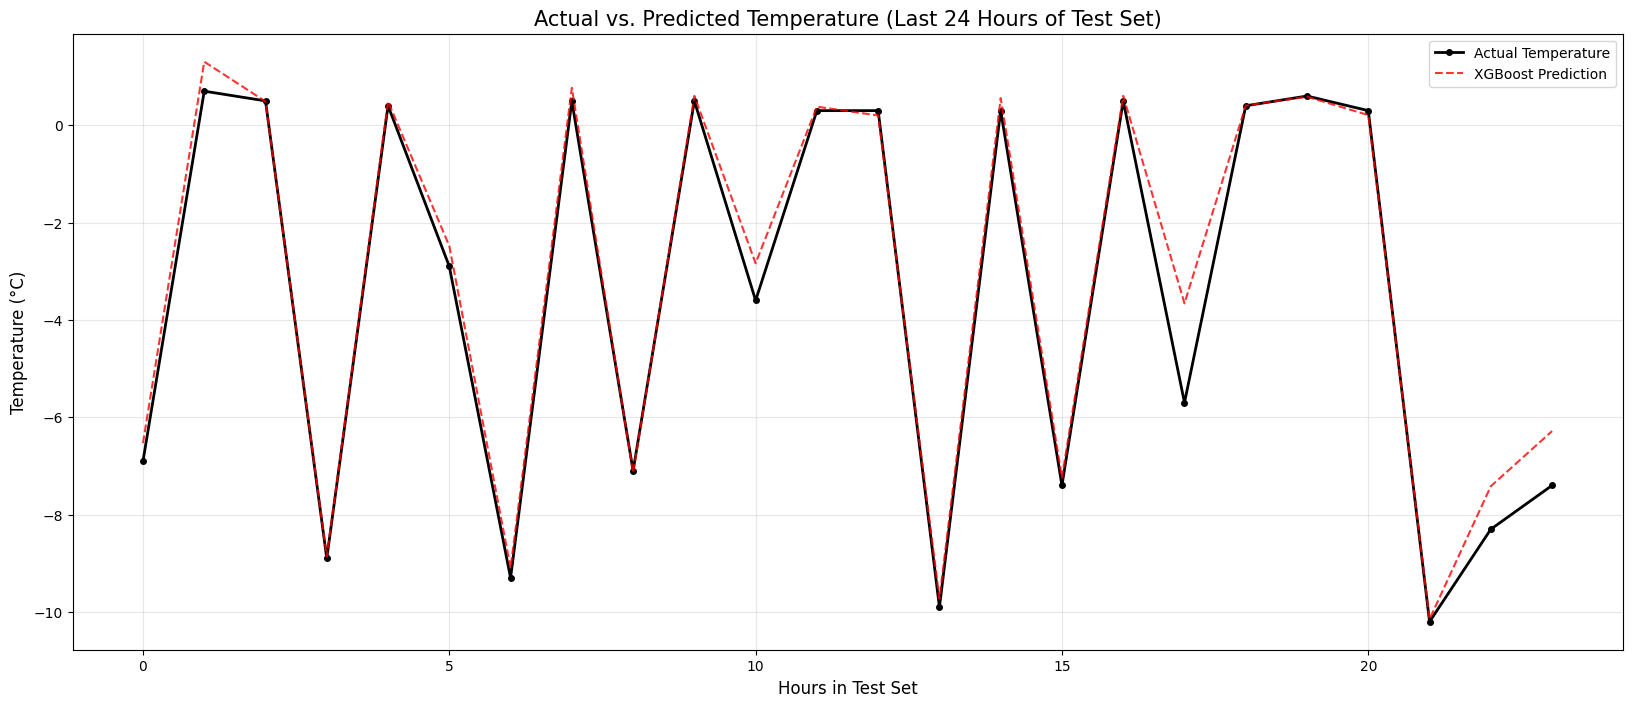

In [198]:


window = 24
time_axis = range(window) 

plt.figure(figsize=(20, 8))

# Plot Actuals
plt.plot(time_axis, y_test.iloc[-window:].values, 
         label='Actual Temperature', color='black', linewidth=2, marker='o', markersize=4)

# Plot XGBoost
plt.plot(time_axis, y_xgb_test[-window:], 
         label='XGBoost Prediction', color='red', linestyle='--', alpha=0.8)


# Formatting
plt.title(f'Actual vs. Predicted Temperature (Last {window} Hours of Test Set)', fontsize=15)
plt.xlabel('Hours in Test Set', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [193]:
df.describe()

,time,lat,lon,air_temperature,highest_temperature,lowest_temperature,relative_humidity,wind_speed,maximum_wind_speed,minimum_wind_speed,...,temp_change_1,air_pressure_lag_1,relative_humidity_lag_1,pressure_diff_3h,hour,month,hour_sin,hour_cos,target_diff,temp_lag_24
count,12131,12131.000000,12131.000000,12131.000000,12131.000000,12131.000000,12131.000000,12131.000000,12131.000000,12131.000000,...,12131.000000,12131.000000,12131.000000,12131.00000,12131.000000,12131.000000,1.213100e+04,1.213100e+04,12131.000000,12131.000000
mean,2026-01-18 03:04:49.638117,62.783916,23.932147,-7.988797,-7.662262,-8.321696,87.033138,2.937590,3.522537,2.351035,...,-0.002869,1015.344654,87.033221,-0.01450,11.478773,4.705878,1.464110e-03,2.523856e-03,-0.003116,-7.942074
min,2025-12-05 23:00:00,60.200000,21.650000,-38.600000,-38.200000,-38.800000,44.000000,0.000000,0.000000,0.000000,...,-5.000000,982.300000,44.000000,-20.90000,0.000000,1.000000,-1.000000e+00,-1.000000e+00,-5.000000,-38.600000
25%,2025-12-27 00:00:00,60.510000,22.200000,-13.600000,-13.100000,-14.000000,83.000000,1.400000,2.000000,0.900000,...,-0.300000,1007.400000,83.000000,-0.70000,5.000000,1.000000,-7.071068e-01,-7.071068e-01,-0.300000,-13.600000
50%,2026-01-18 02:00:00,63.090000,24.960000,-7.300000,-7.100000,-7.600000,87.000000,2.700000,3.200000,2.100000,...,0.000000,1015.500000,87.000000,0.00000,11.000000,2.000000,1.224647e-16,6.123234e-17,0.000000,-7.300000
75%,2026-02-09 03:30:00,64.930000,25.350000,-1.100000,-0.900000,-1.300000,93.000000,4.100000,4.700000,3.500000,...,0.300000,1024.400000,93.000000,0.70000,17.000000,12.000000,7.071068e-01,7.071068e-01,0.300000,-1.000000
max,2026-03-02 05:00:00,66.560000,25.830000,8.400000,8.500000,8.300000,100.000000,14.100000,16.200000,13.300000,...,8.900000,1037.500000,100.000000,9.00000,23.000000,12.000000,1.000000e+00,1.000000e+00,8.900000,8.400000
std,NaN,2.334429,1.580504,8.595720,8.474814,8.724374,8.266544,1.941225,2.113796,1.796608,...,0.708436,10.864289,8.266449,1.48772,6.932481,4.842061,7.068916e-01,7.073742e-01,0.708652,8.637387
